Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,201 (47.66 KB)

 Trainable params: 12,201 (47.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0932 - val_loss: 0.0240
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0145 - val_loss: 0.0103
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0091 - val_loss: 0.0079
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0076 - val_loss: 0.0070
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0069 - val_loss: 0.0065
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057 - val_loss: 0.0054
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0054 - val_loss: 0.0052
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - val_loss: 0.0049
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0049 - val_l

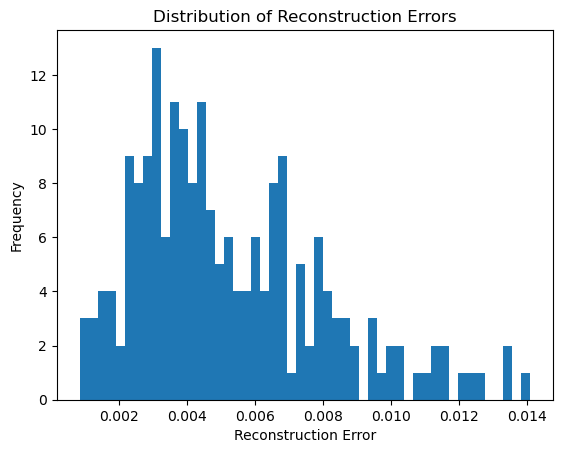

Threshold for anomalies: 0.009032784029841423
Number of anomalies detected: 20


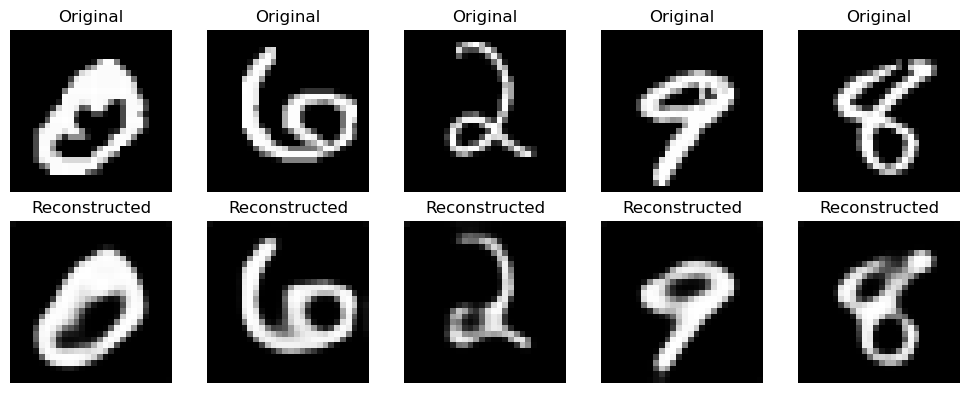

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

if __name__ == "__main__":

 

    # Load MNIST dataset

    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

 

    # Normalize data (scale pixel values between 0 and 1)

    x_train = x_train.astype("float32") / 255.0

    x_test = x_test.astype("float32") / 255.0

 

    # Reshape for neural network input

    x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))

    x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

 

    # Use only digit "0" for training (normal data)

    normal_data = x_train[y_train == 0]

 

    # Prepare test set with some anomalies (digits other than 0)

    anomalous_data = x_test[(y_test != 0)]

    test_data = np.concatenate([normal_data[:100], anomalous_data[:100]])  # 100 normal, 100 anomalies

    
    def get_cnn_autoencoder(input_data_shape):
       
        
        #the input size is 1x28x28
        input_img = keras.Input(shape=(input_data_shape[0], input_data_shape[1], 1))
        
        model = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)   #the output of this layer is 28x28
        model = keras.layers.MaxPooling2D((2, 2), padding='same')(model)                #the output of this layer  is 32[14x14]

        #create a convolutional layer with 1 filters in layer 2 with kernel size of 3x3 and activation function of relu and max pooling of 2x2 32[14x14]
        model = keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(model)    #the output of this layer  is 16[14x14]
        model = keras.layers.MaxPooling2D((2, 2), padding='same')(model)  #the output of this layer is 16[7x7]

        model = keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(model)    #the output of this layer  is 8[7x7]
        
        
        #create a decoder
        #upsample the output of the encoder
        model = keras.layers.UpSampling2D((2, 2))(model)  #the output of this layer is 8[14x14]
        model = keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(model)  #the output of this layer is 16[14x14]
        
        model = keras.layers.UpSampling2D((2, 2))(model)  #the output of this layer is 16[28x28]
        model = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(model)  #the output of this layer is 32[28x28]

        model = keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(model)
       
        autoencoder = keras.Model(input_img, model)
        
        autoencoder.compile(optimizer='adam', loss='mse')
        autoencoder.summary()

        return autoencoder






    # Shuffle test data

    np.random.shuffle(test_data)

    autoencoder = get_cnn_autoencoder(

        input_data_shape=(28, 28)

    )

 

    autoencoder.fit(normal_data[100:], normal_data[100:],

                    epochs=20,

                    batch_size=64,

                    shuffle=True,

                    validation_split=0.2)

 

    # Get reconstructed images

    reconstructed_images = autoencoder.predict(test_data)

 

    # Compute reconstruction error (MSE)

    mse_errors = np.mean(np.power(test_data - reconstructed_images, 2), axis=(1, 2, 3))

 

    # Plot histogram of errors

    plt.hist(mse_errors, bins=50)

    plt.xlabel("Reconstruction Error")

    plt.ylabel("Frequency")

    plt.title("Distribution of Reconstruction Errors")

    plt.show()

 

    # Set threshold (e.g., 95th percentile)

    threshold = np.percentile(mse_errors, 90)

    print(f"Threshold for anomalies: {threshold}")

 

    # Identify anomalies

    anomalies = mse_errors > threshold

    print(f"Number of anomalies detected: {np.sum(anomalies)}")

 

    # Select some normal and anomalous examples

    idx = np.random.choice(np.where(anomalies)[0], 5)  # Choose 5 anomalies

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))

 

    for i, index in enumerate(idx):

        # Original

        axes[0, i].imshow(test_data[index].reshape(28, 28), cmap="gray")

        axes[0, i].set_title("Original")

        axes[0, i].axis("off")

       

        # Reconstructed

        axes[1, i].imshow(reconstructed_images[index].reshape(28, 28), cmap="gray")

        axes[1, i].set_title("Reconstructed")

        axes[1, i].axis("off")

 

    plt.tight_layout()

    plt.show()